In [2]:
#importing libirary and loading data 
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import confusion_matrix, adjusted_rand_score, silhouette_score, davies_bouldin_score,calinski_harabasz_score
from sklearn.decomposition import PCA

df_processed = pd.read_csv("../data/heart_processed.csv")
X = df_processed[['thal', 'ca', 'slope', 'thalach', 'exang', 'sex', 'oldpeak', 'cp']]
y = df_processed['target']

Davies-Bouldin Index: 0.5497050794783369
Silhouette Score: 0.5902051402035358
Calinski-Harabasz Index: 547.344038498357
KMeans ARI: 0.10287697330210023

Confusion Matrix (KMeans):
 [[ 58  80]
 [ 22 143]]
Best Hyperparameters: {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10}
Best Silhouette Score: 0.5902051402035358


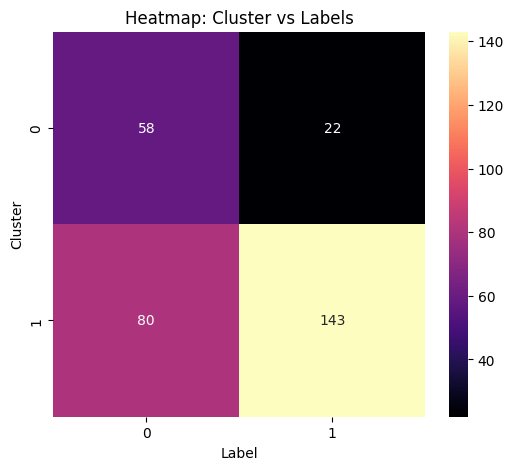

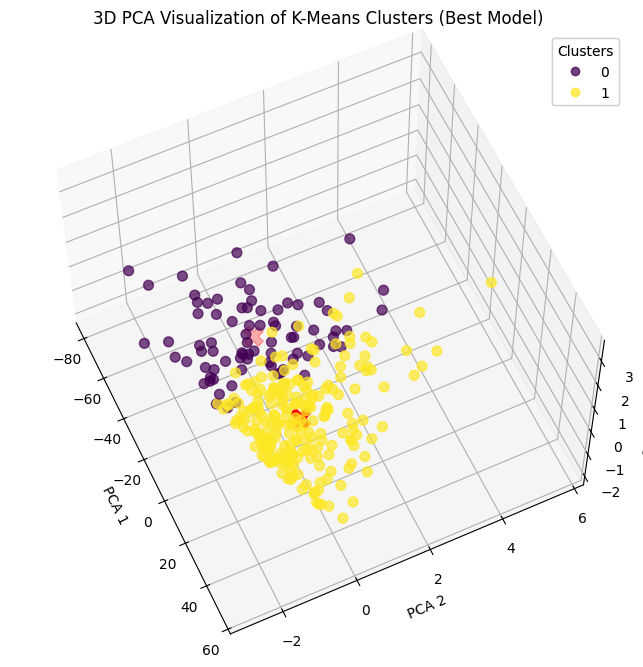

In [3]:
#K-means cluster with search grid
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'n_init': [10, 30, 50],
    'max_iter': [300, 500],
    'init': ['k-means++', 'random']
}
best_score = -1
best_params = None
best_labels = None

for params in ParameterGrid(param_grid):
    kmeans = KMeans(**params, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_score = score
        best_params = params
        best_labels = labels

best_kmeans = KMeans(**best_params, random_state=42)
best_labels = best_kmeans.fit_predict(X)
centroids = pd.DataFrame(best_kmeans.cluster_centers_, columns=X.columns)

df_compare = pd.DataFrame({"Cluster": best_labels, "Label": y})
cluster_summary = df_compare.groupby(["Cluster", "Label"]).size().unstack(fill_value=0)
cluster_summary["Total"] = cluster_summary.sum(axis=1)
cluster_summary["% Healthy (0)"] = (cluster_summary[0] / cluster_summary["Total"] * 100).round(2)
cluster_summary["% Sick (1)"] = (cluster_summary[1] / cluster_summary["Total"] * 100).round(2)


print("Davies-Bouldin Index:", davies_bouldin_score(X, best_labels))
print("Silhouette Score:", silhouette_score(X, best_labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(X, best_labels))
print("KMeans ARI:", adjusted_rand_score(y, best_labels))
print("\nConfusion Matrix (KMeans):\n", confusion_matrix(y, best_labels))
print("Best Hyperparameters:", best_params)
print("Best Silhouette Score:", best_score)


plt.figure(figsize=(6,5))
sns.heatmap(cluster_summary[[0,1]], annot=True, fmt="d", cmap="magma")
plt.title("Heatmap: Cluster vs Labels")
plt.xlabel("Label")
plt.ylabel("Cluster")
plt.show()


pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X)
centroids_3d = pca.transform(best_kmeans.cluster_centers_)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
    c=best_labels, cmap='viridis', alpha=0.7, s=50
)
ax.scatter(
    centroids_3d[:,0], centroids_3d[:,1], centroids_3d[:,2],
    c='red', marker='X', s=200, label='Centroids'
)
ax.view_init(elev=60, azim=-25)
ax.set_title("3D PCA Visualization of K-Means Clusters (Best Model)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()

Davies-Bouldin Index: 0.2234393157111996
Silhouette Score: 0.623409079482984
Calinski-Harabasz Index: 12.72202089462962
Agglomerative ARI: 0.0012913537561437133

Confusion Matrix (Agglomerative):
 [[  0 137   1]
 [  0 165   0]
 [  0   0   0]]
Best Hyperparameters: {'method': 'average', 't': 2}
Best Silhouette Score: 0.623409079482984


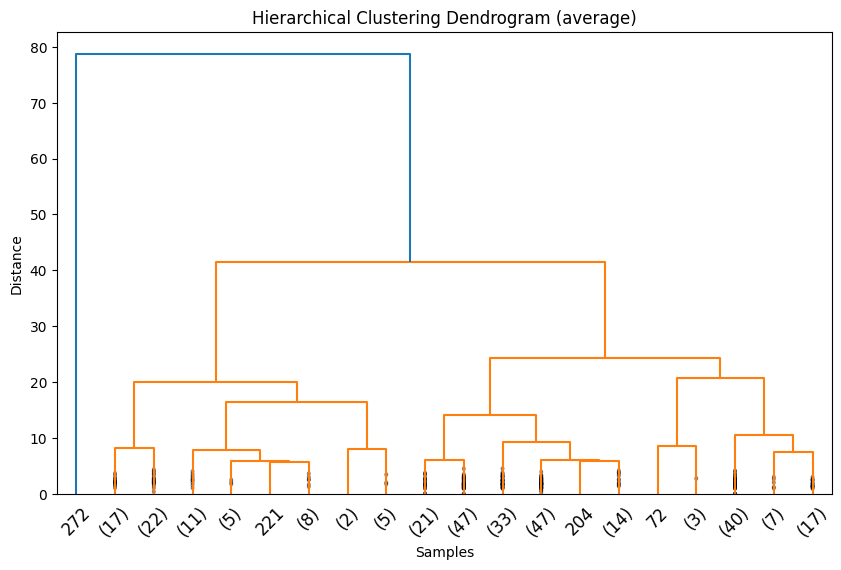

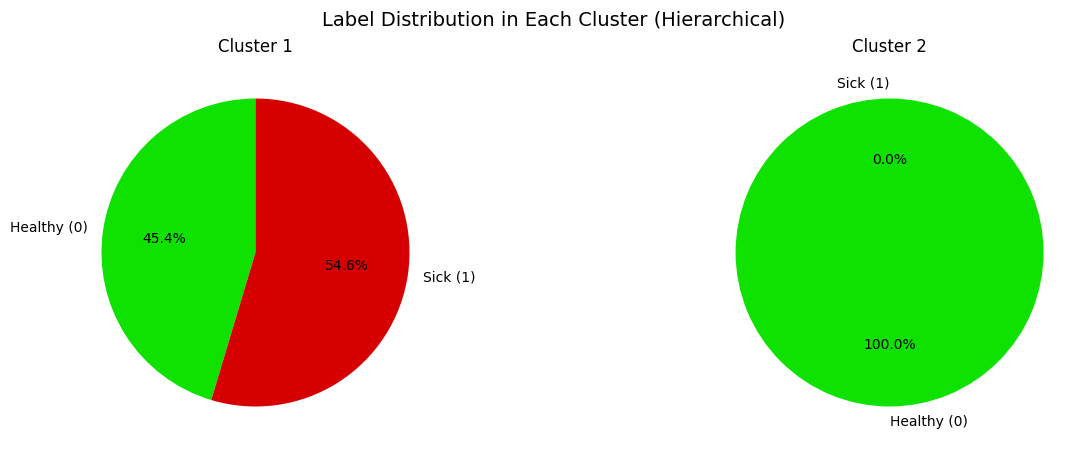

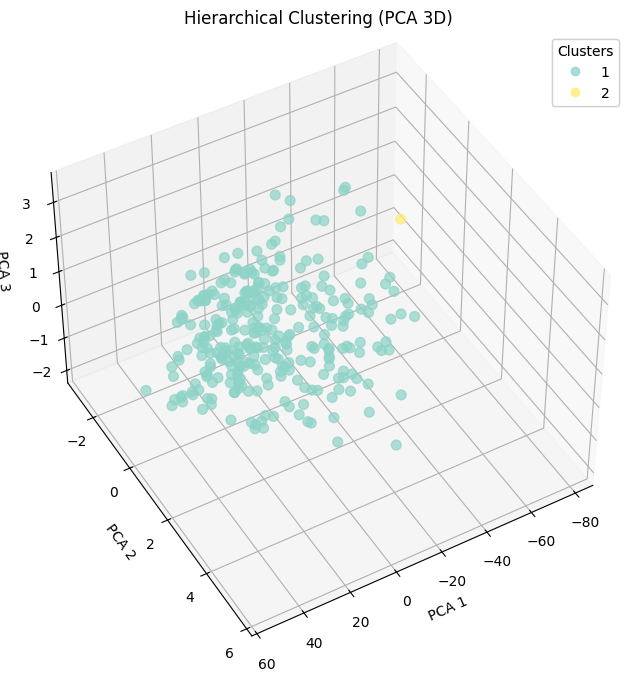

In [5]:
# Hierarchical Clustering with search grid
from sklearn.model_selection import ParameterGrid
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, confusion_matrix, adjusted_rand_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

param_grid = {
    't': [2, 3, 4, 5],
    'method': ['ward', 'complete', 'average', 'single']
}

best_score = -1
best_params = None
best_labels = None

linkage_cache = {}

for params in ParameterGrid(param_grid):

    if params['method'] not in linkage_cache:
        linkage_cache[params['method']] = linkage(X, method=params['method'])

    linked = linkage_cache[params['method']]
    labels = fcluster(linked, t=params['t'], criterion='maxclust')

    if len(set(labels)) < 2:
        continue

    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_params = params
        best_labels = labels


df_hc_compare = pd.DataFrame({"Cluster": best_labels, "Label": y})
hc_summary = df_hc_compare.groupby(["Cluster", "Label"]).size().unstack(fill_value=0)

hc_summary["Total"] = hc_summary.sum(axis=1)
hc_summary["% Healthy (0)"] = (hc_summary[0] / hc_summary["Total"] * 100).round(2)
hc_summary["% Sick (1)"] = (hc_summary[1] / hc_summary["Total"] * 100).round(2)


print("Davies-Bouldin Index:", davies_bouldin_score(X, best_labels))
print("Silhouette Score:", silhouette_score(X, best_labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(X, best_labels))
print("Agglomerative ARI:", adjusted_rand_score(y, best_labels))  # fixed
print("\nConfusion Matrix (Agglomerative):\n", confusion_matrix(y, best_labels))  # fixed
print("Best Hyperparameters:", best_params)
print("Best Silhouette Score:", best_score)


linked = linkage(X, method=best_params['method'])
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=12,
           show_contracted=True)
plt.title(f"Hierarchical Clustering Dendrogram ({best_params['method']})")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


fig, axes = plt.subplots(1, len(hc_summary), figsize=(15, 5))

for i, ax in zip(hc_summary.index, axes.flatten()):
    sizes = [hc_summary.loc[i, 0], hc_summary.loc[i, 1]]
    labels_pie = ["Healthy (0)", "Sick (1)"]
    ax.pie(sizes, labels=labels_pie, autopct='%1.1f%%',
           startangle=90, colors=["#0FE200", "#d70000"])
    ax.set_title(f"Cluster {i}")

plt.suptitle("Label Distribution in Each Cluster (Hierarchical)", fontsize=14)
plt.show()


pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=best_labels, cmap='Set3', alpha=0.7, s=50
)

ax.view_init(elev=45, azim=60)
ax.set_title("Hierarchical Clustering (PCA 3D)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()